In [1]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
import paths
import jax.numpy as jnp
from tqdm import tqdm, trange
import weighting
import scipy.integrate as sint
import intensity_models
from inspect import getfullargspec

import fisher_snrs
from fisher_snrs import compute_snrs
#import mock_injections
#from mock_injections import *
import matplotlib.pyplot as plt

import jax
from importlib import reload 
jax.local_devices()
jax.config.update("jax_enable_x64", True)


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


/mnt/home/amoran/miniforge3/envs/GW_all/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-09 10:58:13.169978: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.9.86). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
import jax
from importlib import reload 
jax.local_devices()
jax.config.update("jax_enable_x64", True)


In [11]:
SENSITIVITIES = {'aligo': lalsim.SimNoisePSDaLIGODesignSensitivityP1200087,
                'aplus': lalsim.SimNoisePSDaLIGOAPlusDesignSensitivityT1800042,
                'CE': lalsim.SimNoisePSDCosmicExplorerP1600143}

population_parameters = dict()
config_file = '../reproduce/configs/paper_params.txt'
#outfile = 'new_mock_inj_cut.h5'#'mock_injections_o3_zp1.h5'

population_parameters = dict()
with open(config_file) as param_file:
    for line in param_file:
        (key, val) = line.split('=')
        population_parameters[key.strip()] = val.strip()
        try:
            population_parameters[key.strip()] = float(val.strip())
        except ValueError:
            pass
snr_threshold = 1
#population_parameters.pop('snr_threshold')
ndraw = int(population_parameters.pop('ndraw', int(5e4)))
sensitivity='o3_PSD'
#sensitivity = population_parameters.pop('sensitivity', 'aligo')
detectors = population_parameters.pop('detectors', 'H1').split(',')
custom_cosmo = intensity_models.FlatwCDMCosmology(population_parameters['h'], population_parameters['Om'], population_parameters['w'], population_parameters['zmax'])
population_parameters['cosmo'] = custom_cosmo
print("Using the following custom population_parameters: " + str(population_parameters))

Using the following custom population_parameters: {'h': 0.674, 'Om': 0.315, 'w': -1.0, 'a': 2.0, 'b': 1.0, 'c': 2.5, 'mpisn': 35.0, 'mbhmax': 45.0, 'sigma': 0.05, 'fpl': 0.04, 'lam': 3.0, 'kappa': 7.0, 'zp': 1.0, 'mpisndot': 5.0, 'zmax': 1.9, 'mbh_min': 5.0, 'delta_m': 2.5, 'beta': -1.0, 'snr_threshold': 1.0, 'cosmo': FlatwCDMCosmology(h=0.674, Om=0.315, w=-1.0, zmax=1.9, ninterp=1024, zinterp=Array([0.00000000e+00, 1.04131475e-03, 2.08371384e-03, ...,
       1.89396980e+00, 1.89698333e+00, 1.90000000e+00],      dtype=float64), dcinterp=Array([0.00000000e+00, 4.63057878e-03, 9.26369560e-03, ...,
       5.15257946e+00, 5.15722323e+00, 5.16186519e+00],      dtype=float64), dlinterp=Array([0.00000000e+00, 4.63540067e-03, 9.28299849e-03, ...,
       1.49114093e+01, 1.49403897e+01, 1.49694090e+01],      dtype=float64), ddlinterp=Array([4.44795252, 4.45502339, 4.46209345, ..., 9.61530365,
       9.61819823, 9.62109004], dtype=float64), vcinterp=Array([0.00000000e+00, 4.15905286e-07, 3.329978

In [12]:
population_parameters['c']

2.5

In [13]:
class ZPDF(object):
    def __init__(self, lam, kappa, zp, zmax, cosmo):
        self.lam = lam
        self.kappa = kappa
        self.zp = zp

        self.zmax = zmax
        self.cosmo = cosmo

        self.zinterp = np.expm1(np.linspace(np.log(1), np.log(1+self.zmax), 1024))
        self.norm = 1

        unnorm_pdf = self(self.zinterp)
        
        self.norm = 1/np.trapz(unnorm_pdf, self.zinterp)
        self.pdfinterp = unnorm_pdf * self.norm

        self.cdfinterp = sint.cumtrapz(self.pdfinterp, self.zinterp, initial=0)

    def __call__(self, z):
        if self.cosmo == 'default':
            return self.norm*(1+z)**self.lam / (1 + ((1+z)/(1+self.zp))**self.kappa) * Planck18.differential_comoving_volume(z).to(u.Gpc**3/u.sr).value / (1+z)
        else:
            return self.norm*(1+z)**self.lam / (1 + ((1+z)/(1+self.zp))**self.kappa) * (self.cosmo.dVCdz(z)) / (1+z)

    def icdf(self, c):
        return np.interp(c, self.cdfinterp, self.zinterp)
    

class InterpolatedPDF(object):
    def __init__(self, xs, cdfs):
        self.xs = xs
        self.cdfs = cdfs / cdfs[-1]
        self.pdfs = np.diff(cdfs) / np.diff(xs)

    def __call__(self, x):
        x = np.atleast_1d(x)
        i = np.searchsorted(self.xs, x)-1

        return self.pdfs[i]
    
    def icdf(self, c):
        return np.interp(c, self.cdfs, self.xs)

class PowerLawPDF(object):
    def __init__(self, alpha, a, b):
        assert alpha > 1

        self.alpha = alpha
        self.a = a
        self.b = b

        self.norm = (self.a - (self.a/self.b)**self.alpha*self.b)/(self.a*(self.alpha-1))

    def __call__(self, x):
        return (self.a/x)**self.alpha/self.a/self.norm
    
    def icdf(self, c):
        return ((self.a**self.alpha*self.b*c + self.a*self.b**self.alpha*(1-c))/(self.a*self.b)**self.alpha)**(1/(1-self.alpha))

In [14]:
ndraw=int(4e5)
import scipy

In [15]:
a=(0-population_parameters["zp"])/(population_parameters["zp"])
b=(population_parameters["zmax"]-population_parameters["zp"])/(population_parameters["zp"])
zpdf = scipy.stats.truncnorm(a, b, loc=population_parameters["zp"], scale=(population_parameters["zp"]))
#zpdf = scipy.stats.uniform(a, b, loc=population_parameters["zp"], scale=(population_parameters["zp"]))
#PowerLawPDF(1.9, population_parameters['zp'], population_parameters["zmax"]
#ZPDF(lam=population_parameters["lam"], kappa=population_parameters["kappa"], zp=population_parameters["zp"], zmax = population_parameters.get("zmax", 20), cosmo=population_parameters["cosmo"])


a=(0-population_parameters["mpisn"])/(2*population_parameters["mpisn"])
#b=(population_parameters["zmax"]-population_parameters["mbhmax"])/(population_parameters["zp"]/2)
mpdf = scipy.stats.truncnorm(a, np.inf, loc=population_parameters["mpisn"], scale=(2*population_parameters["mpisn"]))

#mpdf = PowerLawPDF(1.8, population_parameters["mbh_min"], 400)

rng = np.random.default_rng()
z = zpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
m = mpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
offset=population_parameters['mbh_min']/m
qpdf = scipy.stats.uniform(loc=0+offset, scale=1-offset) #goes from loc to loc+scale
q = qpdf.ppf(rng.uniform(0, 1, size=ndraw))  

#m = mpdf.icdf(rng.uniform(low=0, high=1, size=ndraw))
#mtpdf = PowerLawPDF(2, m+population_parameters['mbh_min'], 2 * m)
#mt_min = m + population_parameters["mbh_min"]
#mt_max = 2*m
#loc = (mt_max + mt_min)/2
#scale = (mt_max - mt_min)/2
#a = (mt_min - loc)/scale  # should be -1
#b = (mt_max - loc)/scale  # should be 1
#mtpdf = scipy.stats.truncnorm(a, b, loc=loc, scale=scale)


#mt = mtpdf.icdf(rng.uniform(low=0, high=1, size=ndraw))
#mt = mtpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
mt=m+q*m
m2 = mt - m
#q = m2/m

print("calculating pdraws")
pdraw = mpdf.pdf(m)*zpdf.pdf(z)*(1.0 / (1.0 - offset))#qpdf.pdf(q)#*(mtpdf.pdf(mt))*m)

m1d = m * (1 + z)
iota = np.arccos(rng.uniform(low=-1, high=1, size=ndraw))

ra = rng.uniform(low=0, high=2*np.pi, size=ndraw)
dec = np.arcsin(rng.uniform(low=-1, high=1, size=ndraw))

# 0 < psi < pi, uniformly distributed
psi = rng.uniform(low=0, high=np.pi, size=ndraw)
gmst = rng.uniform(low=0, high=2*np.pi, size=ndraw)

print("assigning spins")

s1x, s1y, s1z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))
s2x, s2y, s2z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))


print("calculating dLs")

dm1sz_dm1ddl = weighting.dm1sz_dm1ddl(z, cosmo=population_parameters['cosmo'])
dL = population_parameters['cosmo'].dL(z)# dL in Gpc 
zeros=jnp.zeros(len(m))
df = {
    'm1': jnp.array(m),
    'q': jnp.array(q),
    'z': jnp.array(z),
    'dL': jnp.array(dL), #in GPC here
    'm1d': jnp.array(m1d),
    'iota': jnp.array(iota),
    'ra': jnp.array(ra),
    'dec': jnp.array(dec),
    'psi': jnp.array(psi),
    'gmst': jnp.array(gmst),
    's1x': zeros, #jnp.zeros(len(m)), 
    's1y': zeros, #jnp.zeros(len(m)), 
    's1z': zeros, #jnp.zeros(len(m)), 
    's2x': zeros, #jnp.zeros(len(m)), 
    's2y': zeros, #jnp.zeros(len(m)), 
    's2z': zeros, #jnp.zeros(len(m)), 
    'pdraw_mqz': jnp.array(pdraw),
    'dm1sz_dm1ddl': jnp.array(dm1sz_dm1ddl),}

if snr_threshold>0:
    SNR_comp = np.zeros(ndraw)
    num_left = ndraw
    tot_num = ndraw
    batch_num=400
    num_loops=int(np.trunc(ndraw/batch_num)+1)
    for i in range(num_loops):
        if num_left==0:
            break
        start=int(tot_num - num_left)
        stop=int(tot_num - num_left + batch_num)
        if num_left > batch_num:
            df_here = {k: v[start:stop] for k, v in df.items()}
        else:
            df_here = {k: v[start:] for k, v in df.items()}
        SNR_batch = fisher_snrs.compute_snrs_batch(df_here, detectors=detectors, sensitivity=sensitivity)
        SNR_batch.block_until_ready()

        SNR_comp[start:stop]= SNR_batch
        del df_here, SNR_batch
        if i% 10 ==0:
            print("batch done, num left: ", num_left)
        num_left -= batch_num        
    df['SNR']=SNR_comp       
                #jnp.asarray(fisher_snrs.compute_snrs_batch(df, detectors=detectors, sensitivity=sensitivity))
        #df['SNR'] = jnp.asarray(fisher_snrs.compute_snrs(df, detectors=detectors, sensitivity=sensitivity))
        #df['SNR_old'] = jnp.asarray(fisher_snrs.compute_snrs_old(pd.DataFrame(df), detectors=detectors, sensitivity=sensitivity))
else:
    df['SNR'] = 10000000
    SNR_comp=10000000

df['SNR'] = SNR_comp


# Convert dict of JAX arrays -> dict of NumPy arrays
df_np = {k: np.asarray(v) for k, v in df.items()}

# Build DataFrame
df_pd = pd.DataFrame(df_np)

calculating pdraws
assigning spins
calculating dLs
batch done, num left:  400000
batch done, num left:  396000
batch done, num left:  392000
batch done, num left:  388000
batch done, num left:  384000
batch done, num left:  380000
batch done, num left:  376000
batch done, num left:  372000
batch done, num left:  368000
batch done, num left:  364000
batch done, num left:  360000
batch done, num left:  356000
batch done, num left:  352000
batch done, num left:  348000
batch done, num left:  344000
batch done, num left:  340000
batch done, num left:  336000
batch done, num left:  332000
batch done, num left:  328000
batch done, num left:  324000
batch done, num left:  320000
batch done, num left:  316000
batch done, num left:  312000
batch done, num left:  308000
batch done, num left:  304000
batch done, num left:  300000
batch done, num left:  296000
batch done, num left:  292000
batch done, num left:  288000
batch done, num left:  284000
batch done, num left:  280000
batch done, num lef

In [16]:
cosmo = intensity_models.FlatwCDMCosmology(population_parameters['h'], population_parameters['Om'],
                                           population_parameters['w'], population_parameters['zmax'])


log_dN_obj = intensity_models.LogDNDMDQDV
pop_params = {key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
log_dN_func=log_dN_obj(**pop_params)
log_dN_vals = log_dN_func(df_pd['m1'].values, df_pd['q'].values, df_pd['z'].values)

log_w = log_dN_vals - jnp.log(pdraw) +jnp.log(cosmo.dVCdz(df_pd['z'].values)) -jnp.log1p(df_pd['z'].values)

# stable accept-reject
log_w_max = np.nanmax(log_w)
accept_prob = np.exp(log_w - log_w_max)   # norm
u = rng.uniform(size=len(accept_prob))
sel_mask = u < accept_prob
#n_final=2000
#accepted_idxs = np.where(sel_mask)[0]
#if len(accepted_idxs) < n_final:
#    raise RuntimeError(f"Accepted only {len(accepted_idxs)} < {n_final}.")
#chosen = rng.choice(accepted_idxs,  size=n_final, replace=False)

accepted_idxs = np.where(sel_mask)[0]

# take everything that passed
chosen = accepted_idxs
pdraw_sel = (np.exp(log_dN_func(df_pd['m1'].values, df_pd['q'].values, df_pd['z'].values))  
    * cosmo.dVCdz(df_pd['z'].values)/ ((1+df_pd['z'].values)**2))*cosmo.ddL_dz(df_pd['z'].values) #/ ((1+df_pd['z'].values)* (1+df_pd['z'].values))) # in (m1_source, q, z)
#pdraw_sel_detframe = pdraw_sel / ((1+df_pd['z'].values) * cosmo.ddL_dz(df_pd['z'].values))

df_pd['pdraw_sel']=pdraw_sel #_detframe

df_det = df_pd.iloc[chosen].copy()
df_det = df_det[df_det['SNR'] > snr_threshold]

print(f"Retained {len(df_det)} samples after rejection sampling and applying snr cut.")

Retained 3813 samples after rejection sampling and applying snr cut.


In [9]:
z_space=np.linspace(0, 1.9, 40)
def R_of_z(z, lam=population_parameters['lam'], kappa=population_parameters['kappa'], zp=population_parameters['zp']):
    num=(1+z)**lam
    denom=1+(((1+z)/(1+zp))**kappa)
    dVcdz=cosmo.dVCdz(z)
    return num/denom* dVcdz / (1+z)
Rs=R_of_z(z_space)

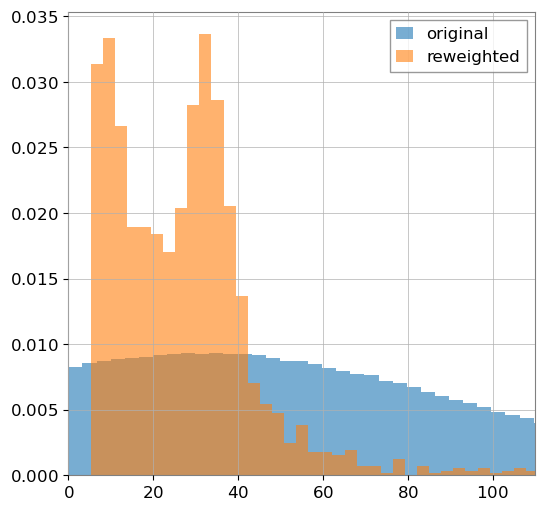

In [191]:
plt.hist(df_pd['m1'], density=True, bins=100, alpha=.6, label='original');
plt.hist(df_det['m1'],density=True, bins=100, alpha=.6, label='reweighted');
plt.legend()
plt.xlim(0, 110);

In [ ]:
# lower c value perferred - we have too many high mass samples/medium mass samples
# lower a perferred - we have too many medium mass samples, dropoff should be sharper for a>1
# flp too high - we have too many high mass samples
# lam too low - we dont have enough mergers at low redshift

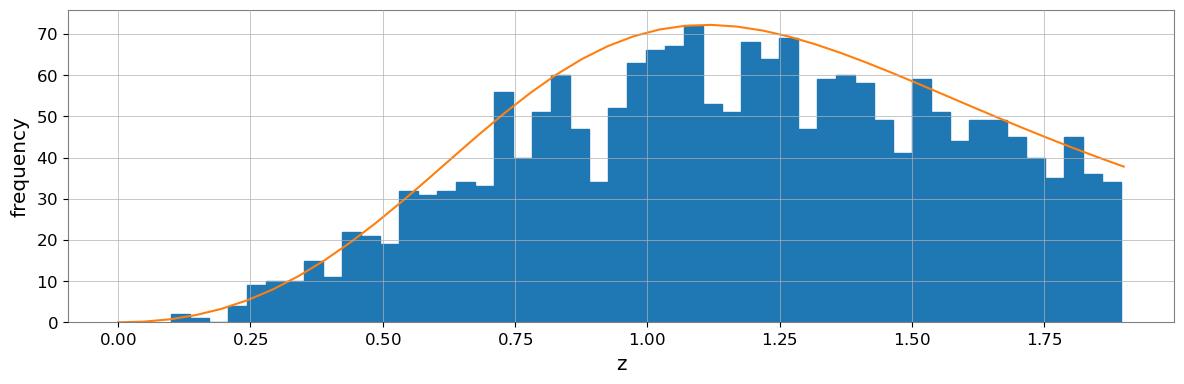

In [135]:
plt.figure(figsize=(12, 4))
plt.hist(jnp.array(df_det['z'].astype(float)), bins=50, histtype='step',  fill=True)
plt.plot(z_space, .06*Rs)
plt.xlabel("z")
plt.ylabel("frequency")
#plt.yscale('log')
#plt.xlim(0, 150)
plt.tight_layout()
plt.show()

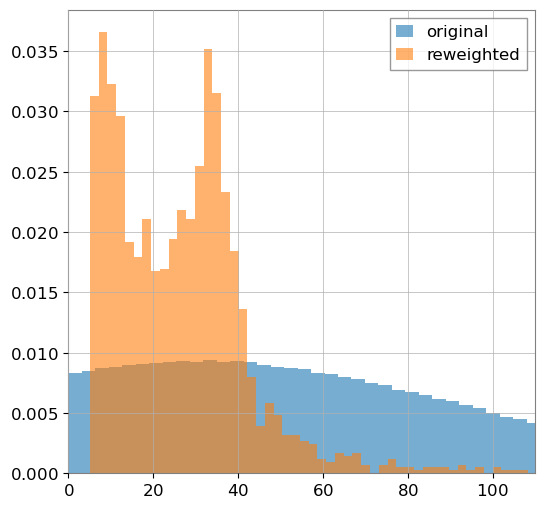

In [136]:
plt.hist(df_pd['m1'], density=True, bins=100, alpha=.6, label='original');
plt.hist(df_det['m1'],density=True, bins=100, alpha=.6, label='reweighted');
plt.legend()
plt.xlim(0, 110);

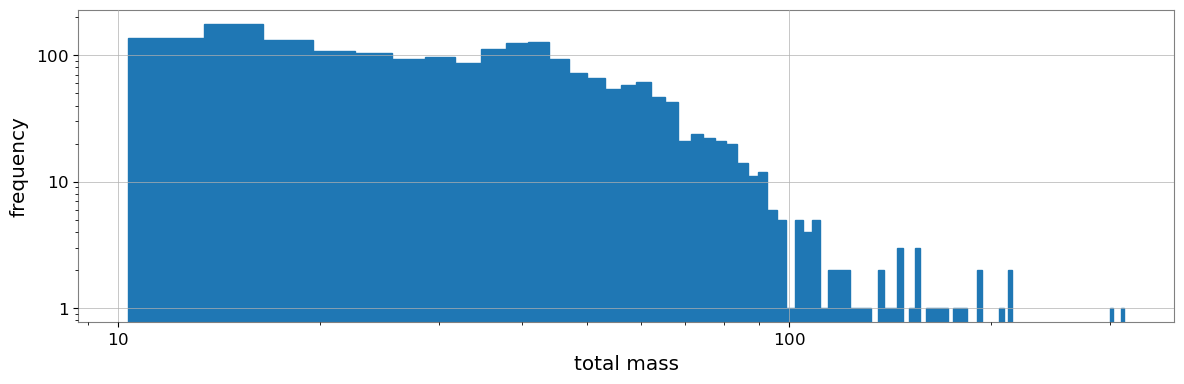

In [192]:
plt.figure(figsize=(12, 4))
plt.hist(jnp.array(df_det['m1'].astype(float))+ jnp.array(df_det['m1'].astype(float)*df_det['q'].astype(float)),
         bins=100, histtype='step',  fill=True)
tot_mass_ex=np.linspace(45, 80, 10)
plt.xlabel("total mass")
plt.ylabel("frequency")
plt.yscale('log')
plt.xscale('log')
#plt.xlim(0, 150)
plt.tight_layout()
plt.show()

In [17]:
df_det.to_hdf('paper_mock_inj.h5', key='true_parameters', mode='a', format='table', append=False)


## Mock observations from this:

In [106]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from astropy.cosmology import Planck18
import astropy.units as u
import dataclasses
from dataclasses import dataclass
import numpy as np
import os.path as op
import pandas as pd
import paths
import seaborn as sns
from tqdm import tqdm
import mock_observations
import weighting
from scipy import stats
from scipy.stats import norm, truncnorm
import bilby

In [255]:
detection_threshold=0
inj = pd.read_hdf('new_mock_inj.h5', key='true_parameters')
inj=inj[0:300]
rng = np.random.default_rng(251286134409181405721219170031242732711)

inj['SNR_OBS'] = inj['SNR']# + rng.normal(loc=0, scale=np.sqrt(1), size=len(inj))

inj_det = inj[inj['SNR_OBS'] > detection_threshold].copy()
#inj_det['mc'] = inj_det['m1'] * (inj_det['q']**(3/5) / ((1 + inj_det['q'])**(1/5)))
#inj_det['dl'] = Planck18.luminosity_distance(inj_det['z'].to_numpy()).to(u.Gpc).value
#inj_det['mc_det'] = inj_det['mc'] * (1 + inj_det['z'])

m1_obs = []
sigma_m1 = []
log_q_obs = []
sigma_log_q = []
z_obs = []
sigma_z = []

for i, row in tqdm(inj_det.iterrows()):
    uncert = mock_observations.Uncertainties.from_snr(row['SNR_OBS'])
    
    m1_obs.append(np.log(row['m1']) + uncert.sigma_log_mc*rng.normal())
    sigma_m1.append(uncert.sigma_log_mc)
    
    b = (0 - np.log(row['q']))/ uncert.sigma_log_q  # upper bound standardized
    log_q_obs.append(np.log(row['q']))#truncnorm.rvs(-np.inf, b, loc=np.log(row['q']), scale=uncert.sigma_log_q))
    sigma_log_q.append(uncert.sigma_log_q)
    
    z_ = row['z'] * row['SNR'] / row['SNR_OBS']
    sigma_z.append(uncert.sigma_log_dl)
    z_obs.append(z_)#np.log(row['dl']) + uncert.sigma_log_dl*rng.normal())

inj_det['m1_obs'] = m1_obs
inj_det['sigma_m1'] = sigma_m1
inj_det['log_q_obs'] = log_q_obs
inj_det['sigma_log_q'] = sigma_log_q
inj_det['z_obs'] = z_obs
inj_det['sigma_z'] = sigma_z
#inj_det['z'] = inj_det['z']
inj_det = inj_det.reset_index(drop=True)
inj_det['evt'] = [f'evt_{i}' for i in inj_det.index]
inj_det.to_hdf('data/obs_newinj_zms.h5', key='observations')

0it [00:00, ?it/s]/tmp/ipykernel_514010/2527696425.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  b = (0 - np.log(row['q']))/ uncert.sigma_log_q  # upper bound standardized
300it [00:00, 21917.63it/s]


In [241]:
reload(weighting)

<module 'weighting' from '/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py'>

In [256]:
pe_samples_full = pd.read_hdf('../src/data/obs_newinj_zms.h5', 'observations')


nsamples = 10  # number of draws per event
m1s, qs, zs, pdraws = [], [], [], []
for n, e in pe_samples_full.groupby('evt'):
    # preallocate arrays for this event
    m1_event = []
    q_event = []
    z_event = []
    pdraw_event = []
    for num in range(nsamples):
        samples = weighting.draw_mock_samples_linear(
            e['m1'].iloc[0],  # detector frame
            e['sigma_m1'].iloc[0],
            np.exp(e['log_q_obs'].iloc[0]), 
            e['sigma_log_q'].iloc[0],
            e['z_obs'].iloc[0],
            e['sigma_z'].iloc[0])
        m1_event.append(samples[0][0])
        q_event.append(samples[1][0])
        z_event.append(samples[2][0])
        pdraw_event.append(samples[3][0])

    # store all samples for this event
    m1s.append(m1_event)
    qs.append(q_event)
    zs.append(z_event)
    pdraws.append(pdraw_event)

# convert to arrays (shape = nevents × nsamples)
m1s = np.array(m1s)
qs = np.array(qs)
zs = np.array(zs)
pdraws = np.array(pdraws)

print("array shapes (we want nevents, nsamples): ", m1s.shape, qs.shape, zs.shape, pdraws.shape)

/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py:287: RuntimeWarning: divide by zero encountered in scalar divide
  a = (0 - (q_obs)) / (sigma_q)
/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py:288: RuntimeWarning: divide by zero encountered in scalar divide
  b = (1 - (q_obs)) / (sigma_q)
/mnt/home/amoran/GW_pop_cosmo_inference/src/weighting.py:292: RuntimeWarning: divide by zero encountered in scalar divide
  a_DL = (0 - (dl_obs)) / (sigma_dl)


array shapes (we want nevents, nsamples):  (300, 10) (300, 10) (300, 10) (300, 10)


In [257]:
df_samples = pd.DataFrame({
    'm1': list(m1s),       # each element is an array of nsamples
    'q': list(qs),
    'z': list(zs),
    'pdraw': list(pdraws)
})
df_samples.to_hdf("pe_newinj_zms.hdf5", key="samples", mode="w")

/tmp/ipykernel_514010/2320298846.py:7: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['m1', 'q', 'z', 'pdraw'], dtype='object')]

  df_samples.to_hdf("pe_newinj_zms.hdf5", key="samples", mode="w")
